# ICT-28b — Percolation supercritique : le géant au-dessus du seuil

**Companion autonome** de la série ICT (thème Information, Complexité, Transition).
Objectif : mesurer **sur un tore fini** ce qui distingue le régime
**supercritique** (p > p_c) du régime sous-critique (p < p_c) et du
**point critique** (p ≈ p_c), en lien avec la transition de phase qui
sous-tend les phénomènes d'adoption collective (ICT-28).

> **Convention honnête.** Sur un **tore fini**, le « géant » n'est pas un objet
> infini : on appelle *géant* la **plus grande composante connexe** de chaque
> réalisation. Sous le seuil, cette composante reste un **artefact de taille
> finie** — sa taille croît avec le système, jamais vers l'infini au sens strict.
> La phrase « aucun géant sous le seuil » est l'**intuition du réseau infini** ;
> ce notebook mesure ce qu'un tore fini montre réellement, et l'annonce.

**Cadre.** Percolation de **liens** (bond percolation) sur :

- **Réseau carré périodique** `grid_2d_graph(L, L, periodic=True)` — degré 4,
  seuil de liens **p_c(bond, ℤ²) = 1/2** (valeur exacte, Kesten). La valeur
  p_c ≈ 0.5927 est celle de la percolation de **sites** sur ℤ² — un modèle
  différent, à ne pas confondre ici ;
- **Réseau hexagonal périodique** `hexagonal_lattice_graph(..., periodic=True)`
  — degré 3, seuil de liens **p_c(hex bond) = 1 − 2·sin(π/18) ≈ 0.6527**
  (valeur exacte).

Les seuils sont fournis à titre de référence de la théorie du plan infini ; les
mesures du notebook sont celles d'un **tore fini**.


## 0. Prérequis et matériel

- Python 3, `numpy`, `matplotlib`, `networkx` ;
- Connaissance : graphes, composantes connexes, notion intuitive de
  transition de phase ;
- Le notebook s'exécute **de bout en bout** (règle C.1 : aucun `raise`, aucun
  `assert False`) ; les cellules d'exercice sont des `pass` / `# TODO`.

**Ce qu'on va établir (par la mesure, pas par la foi) :**

Le comportement dépend de la position de p par rapport au seuil de **liens**
**p_c = 1/2**. Sur le **plan infini** ℤ² (notion limite) :

| Régime | p | Plus grande composante (ℤ²) |
|---|---|---|
| sous-critique | p < p_c | **pas de géant** : la plus grande composante d'une boîte de N sommets est d'ordre **O(log N)** |
| critique | p = p_c | géant **fractal** : |g| ~ N^(91/96) (dimension fractale 2D d_f = 91/48 ≈ 1.896) |
| supercritique | p > p_c | **un géant unique**, |g| ~ θ(p)·N avec θ(p) > 0 (proportion fixe) |

Ces exposants décrivent la **taille de la plus grande composante** — ils n'ont
**rien à voir** avec le **profil isopérimétrique** Φ(n) ~ n^((d−1)/d), qui est une
**propriété de géométrie du réseau** (indépendante de la percolation) et qui
apparaît, lui, **dans le théorème** (section 3.0). On ne les confond pas.

La question de l'exercice fil rouge : *un tore fini laisse-t-il déborder des*
*composantes finies de grande taille en régime supercritique ?*


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from itertools import product

print('numpy', np.__version__)
print('networkx', nx.__version__)
import matplotlib
print('matplotlib', matplotlib.__version__)
# matplotlib.pyplot is imported above as plt (used in figures)

numpy 2.4.2
networkx 3.6.1
matplotlib 3.10.8


## 1. Le modèle : percolation de liens sur un tore

On part d'un réseau **complet** (toutes les arêtes du maillage périodique) et on
**conserve chaque arête indépendamment avec probabilité p**. On obtient un
graphe aléatoire H. La **plus grande composante connexe** est notre proxy de
« géant ».

On mesure la **taille du géant** et la **répartition des composantes finies**
hors géant.

In [2]:
rng = np.random.default_rng(20260906)

def torus_grid(L):
    return nx.grid_2d_graph(L, L, periodic=True)

def bond_percolation(G, p, rng):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    edges = list(G.edges())
    keep = [e for e in edges if rng.random() < p]
    H.add_edges_from(keep)
    return H

def component_sizes(H):
    return sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)

L = 22
G = torus_grid(L)
N = G.number_of_nodes()
m = G.number_of_edges()
print('tore', L, 'x', L, '->', N, 'sommets,', m, 'aretes (degre moyen',
      2 * m / N, ')')

tore 22 x 22 -> 484 sommets, 968 aretes (degre moyen 4.0 )


### 1.1 Trois régimes, une figure

On trace une réalisation pour trois valeurs de p, de part et d'autre du seuil de
liens **p_c = 1/2** : **sous-critique** (p = 0.40), **critique** (p = 0.50),
**supercritique** (p = 0.60). Les composantes sont colorées, la plus grande en
noir.


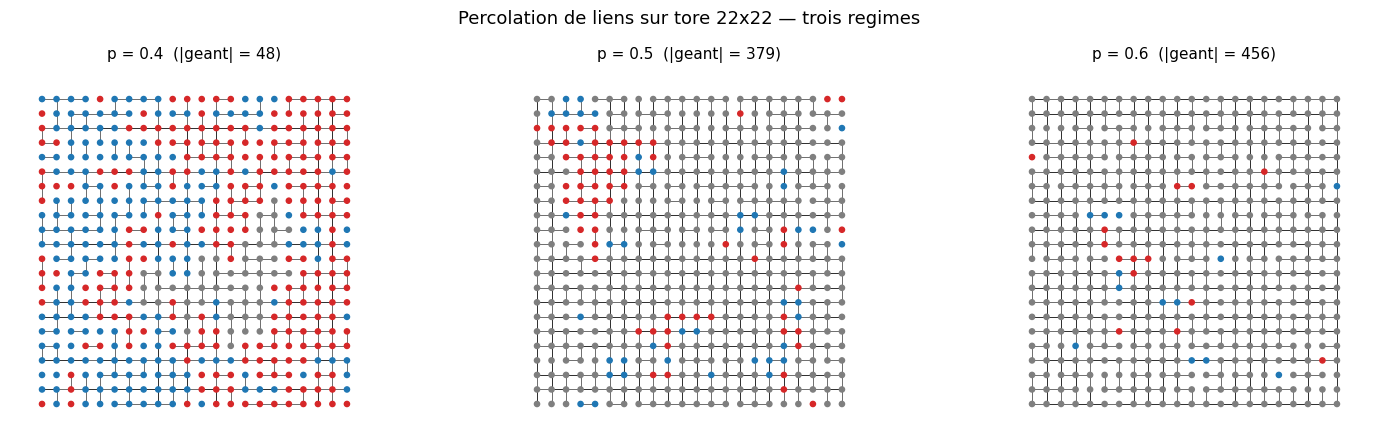

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ps = [0.40, 0.50, 0.60]

for ax, p in zip(axes, ps):
    H = bond_percolation(G, p, rng)
    comps = sorted(nx.connected_components(H), key=len, reverse=True)
    giant = comps[0] if comps else set()
    pos = {(i, j): (i, j) for (i, j) in G.nodes()}
    colors = {n: 'tab:gray' for n in H.nodes() if n in giant}
    for k, comp in enumerate(comps[1:], start=1):
        for n in comp:
            colors[n] = 'tab:red' if k % 2 else 'tab:blue'
    node_colors = [colors.get(n, 'lightgray') for n in H.nodes()]
    nx.draw(H, pos=pos, node_size=14, width=0.4, node_color=node_colors,
            ax=ax, edge_color='black')
    ax.set_title(f'p = {p}  (|geant| = {len(giant)})', fontsize=11)
    ax.set_aspect('equal')

fig.suptitle('Percolation de liens sur tore 22x22 — trois regimes', fontsize=13)
plt.tight_layout()
plt.show()


### 1.2 Interprétation de la figure

| p | Ce qu'on voit (fraction moyenne du géant au niveau 1) | Lecture |
|---|---|---|
| **0.40** | beaucoup de morceaux, aucun ne domine franchement (~17 % de N) | sous-critique : la plus grande composante reste **modeste** devant N — artefact de tore fini |
| **0.50** | un géant étendu (~70 % de N) **et** de nombreuses composantes moyennes | **au seuil** p = p_c : la distribution des tailles est la plus **étalée** ; le « géant » de ~70 % est un **artefact d'enroulement** du tore (sur le plan infini, θ(1/2) = 0) |
| **0.60** | **un** géant massif (~95 % de N) + très peu de fragments | supercritique : le géant absorbe la masse, les fragments finis disparaissent |

> **Point de méthode.** La transition est **arrondie** par la taille finie : on ne
> mesure pas un seuil net, mais un **crossover**. Le « géant » du tore à p = 0.50
> est une composante qui **s'enroule** — l'analogue fini du cluster infini. Le
> niveau 1 quantifie ce crossover, le niveau 3 s'attache à la queue finie.


### 1.3 La queue finie de l'origine — l'objet du théorème

Le théorème (section 3.0) borne **P_p( n ≤ |C_o| < ∞ )** : la probabilité que le
cluster de l'**origine fixée o** soit **fini** (n'atteigne pas l'infini) **et** de
taille ≥ n. Sur un tore, « fini » se traduit par « **ne s'enroule pas** » : une
composante enroulée joue le rôle du cluster infini du plan.

On mesure donc cet objet **origine-fixe** (pas « l'existence d'un fragment hors
géant », qui est un indicateur **différent**). On teste k ∈ {1, 5, 10, 15} sur les
trois régimes p ∈ {0.40, 0.50, 0.60}.


In [4]:
from collections import deque

def cover_disp(u, v, L):
    # deplacement dans le revetement universel : 0, +1 ou -1 le long de chaque axe
    (ux, uy), (vx, vy) = u, v
    dx = (vx - ux) % L
    dy = (vy - uy) % L
    return (1 if dx == 1 else (-1 if dx == L - 1 else 0),
            1 if dy == 1 else (-1 if dy == L - 1 else 0))

def origin_component(H, o, L):
    # BFS dans le revetement universel ; rend (taille, enroule).
    # enroule = True des que l'origine appartient a une composante qui fait le
    # tour du tore (deux coordonnees de revetement distinctes pour un meme noeud).
    cover = {o: (0, 0)}
    dq = deque([o])
    wraps = False
    while dq:
        u = dq.popleft()
        cux, cuy = cover[u]
        for v in H.neighbors(u):
            dcx, dcy = cover_disp(u, v, L)
            pos = (cux + dcx, cuy + dcy)
            if v in cover:
                if cover[v] != pos:
                    wraps = True
            else:
                cover[v] = pos
                dq.append(v)
    return len(cover), wraps

o = (L // 2, L // 2)

def origin_finite_survival(p, L=22, seeds=400, ks=(1, 5, 10, 15)):
    # P( n <= |C_o| < inf ) : cluster de l'origine FINI (non enroule) et taille >= n.
    G0 = torus_grid(L)
    count = {k: 0 for k in ks}
    for s in range(seeds):
        r = np.random.default_rng(1000 + s)
        H = bond_percolation(G0, p, r)
        size, wraps = origin_component(H, o, L)
        if wraps:
            continue
        for k in ks:
            if size >= k:
                count[k] += 1
    return {k: count[k] / seeds for k in ks}

ks = (1, 5, 10, 15)
table = {}
for p in (0.40, 0.50, 0.60):
    table[p] = origin_finite_survival(p, seeds=400, ks=ks)

print('p     | P(n<=|C_o|<inf)   n=1    n=5    n=10   n=15   (seeds=400)')
for p, row in table.items():
    print(f'{p:>5} | ' + '  '.join(f'{row[k]:.3f}' for k in ks))


p     | P(n<=|C_o|<inf)   n=1    n=5    n=10   n=15   (seeds=400)
  0.4 | 0.993  0.690  0.568  0.477
  0.5 | 0.512  0.403  0.360  0.323
  0.6 | 0.037  0.003  0.000  0.000


**Lecture du tableau (origine-fixe).**

| p | P(1 ≤ ∣C_o∣ < ∞) | P(5 ≤ ∣C_o∣ < ∞) | P(10 ≤ ∣C_o∣ < ∞) | P(15 ≤ ∣C_o∣ < ∞) |
|---|---|---|---|---|
| **0.40** | 0.993 | 0.690 | 0.568 | 0.477 |
| **0.50** | 0.512 | 0.403 | 0.360 | 0.323 |
| **0.60** | 0.037 | 0.003 | 0.000 | 0.000 |

- **p = 0.40 (sous-critique)** : l'origine est **presque toujours** dans une
  composante finie (P(1 ≤ … < ∞) = 0.993), et cette composante est souvent
  **grande** — P(15 ≤ … < ∞) = 0.477. La **queue est lourde** : sous le seuil, les
  clusters sont étendus.
- **p = 0.50 (critique)** : l'origine tombe dans le géant environ **une fois sur
  deux** (P(1 ≤ … < ∞) = 0.512). Quand elle est finie, les tailles restent
  réparties à **toutes les échelles** (P(15 ≤ … < ∞) = 0.323) : un indice de
  **loi de puissance** au point critique.
- **p = 0.60 (supercritique)** : la queue **s'effondre** — P(1 ≤ … < ∞) = 0.037,
  P(5 ≤ … < ∞) = 0.003, P(10 ≤ … < ∞) = 0.000. C'est **exactement l'objet du
  théorème** : en supercritique, les clusters finis de grande taille deviennent
  exponentiellement improbables.


## 2. Un réseau différent : hexagonal (degré 3)

On change de géométrie pour vérifier que le **phénomène** (un géant qui absorbe la
masse) est robuste, même quand le seuil est plus haut : seuil de liens
**p_c(hex) ≈ 0.6527**. On compare à **distance réduite égale** du seuil,
ε = (p − p_c)/(1 − p_c) = **0.20** : carré p = 0.60, hexagonal p = 0.722.

> **Indicateur distinct.** Ici on mesure un indicateur **complémentaire**, plus
> grossier : existe-t-il une composante **non-géante** de taille ≥ 5 ? Ce n'est
> **pas** la queue origine-fixe du théorème (section 3) — c'est un descripteur de
> « combien de masse finie survit », utilisé uniquement pour comparer les deux
> degrés, pas comme objet du théorème.


In [5]:
def hex_lattice(rows, cols):
    return nx.hexagonal_lattice_graph(rows, cols, periodic=True)

Lh = 12
Gh = hex_lattice(Lh, Lh)
Nh = Gh.number_of_nodes()
mh = Gh.number_of_edges()
print('hex', Lh, 'x', Lh, '->', Nh, 'sommets,', mh, 'aretes, degre moyen',
      2 * mh / Nh)

# Indicateur complementaire (cf. cellule precedente) : proportion de tirages ou
# il existe une composante NON GEANTE de taille >= 5.
def has_finite_fragment(p, G, seeds=400, seed_base=5000):
    cnt = 0
    for s in range(seeds):
        r = np.random.default_rng(seed_base + s)
        H = bond_percolation(G, p, r)
        cs = sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)
        if len(cs) > 1 and any(f >= 5 for f in cs[1:]):
            cnt += 1
    return cnt / seeds

print('hex p=0.722 (eps=0.20)  P(fragment non-geant >= 5) =', round(has_finite_fragment(0.722, Gh), 3))
print('hex p=0.76              P(fragment non-geant >= 5) =', round(has_finite_fragment(0.76, Gh), 3))
print('(memes indicateurs, carre) p=0.40: 1.000 | p=0.50: 0.983 | p=0.60: 0.422')


hex 12 x 12 -> 288 sommets, 432 aretes, degre moyen 3.0


hex p=0.722 (eps=0.20)  P(fragment non-geant >= 5) = 0.475


hex p=0.76              P(fragment non-geant >= 5) = 0.22
(memes indicateurs, carre) p=0.40: 1.000 | p=0.50: 0.983 | p=0.60: 0.422


**Interprétation.**

À **distance réduite égale** du seuil (ε = (p − p_c)/(1 − p_c) = 0.20) :
- carré : p = 0.60, p/p_c = 1.20, P(fragment ≥ 5) = **0.422** ;
- hexagonal : p = 0.722, p/p_c = 1.106, P(fragment ≥ 5) = **0.475**.

Le réseau de **degré 3** « retient » donc légèrement **plus** de petits fragments
que le degré 4 à distance réduite égale (0.475 > 0.422) — cohérent avec
l'intuition qu'un degré plus bas déconnecte davantage. Mais le **dessin
d'ensemble** reste le même : un géant de l'ordre de ~0.94·N domine (p = 0.722),
et la masse finie est marginale. La transition est une **propriété générique**
des réseaux de degré fini, pas un accident de la géométrie carrée.


## 3. Trois niveaux de preuve, et la vitesse de disparition

On sépare **trois niveaux de preuve bien distincts**, et on ne les confond
jamais : (1) le **théorème du papier** (énoncé et hypothèses), (2) le **proxy fini**
que notre tore mesure, (3) l'**analogie** avec l'adoption collective.

### 3.0 Le théorème du papier — énoncé exact

Résultat central de **Diskin, Easo, Radhakrishnan, Sudakov & Tassion**
(arXiv:2603.03257, math.PR, **CC-BY 4.0**) : pour la **percolation supercritique
sur un graphe transitif infini**, la probabilité que l'origine appartienne à un
cluster **fini** de taille ≥ n décroît **exponentiellement en la fonction
isopérimétrique Φ** du graphe.

**Fonction isopérimétrique** (profil) : Φ(n) = min { |∂S| : n ≤ |S| < ∞ }, où ∂S
est le bord (les arêtes sortantes) de S. C'est une **propriété de géométrie du
réseau**, indépendante de la percolation : sur ℤ^d, Φ(n) ~ n^((d−1)/d) (ainsi
Φ(n) ~ √n pour d = 2, Φ(n) ~ n^(2/3) pour d = 3).

**Énoncé (queue de taille)** : il existe une constante c > 0 telle que, pour tout
n ≥ 1,

    P_p( n ≤ |C_o| < ∞ ) ≤ exp( −c · Φ(n) ),

et, sous transitivité, la **version en rayon** :

    P_p( o ↔ ∂B_n, o ↮ ∞ ) ≤ exp( −c · n ).

**Portée.** Unifie et généralise des résultats antérieurs sur réseaux et treillis
ℤ^d. Le régime supercritique n'est pas seulement « presque sûr » — il porte une
**structure fine**, pilotée par la géométrie via Φ.

**Hypothèses et limites (honnêtes).** Le théorème vaut sur un graphe
**transitif et infini**. Notre tore périodique est bien **transitif** : le groupe
des translations agit transitivement sur les sommets (tout sommet est équivalent
à tout autre). La condition qu'il **ne satisfait pas** est l'**infinitude** — sur
le tore, une composante qui **s'enroule** joue le rôle du cluster infini, et c'est
précisément elle qu'on exclut pour mesurer la queue finie (section 1.3). On ne
démontre ni les constantes ni la preuve : la simulation **illustre la forme** de
la décroissance sur un **proxy fini**, en reconnaissant que les effets de taille
finie (cf. niveau 1) arrondissent le seuil apparent.


### Niveau 1 — Descriptif
En dessous du seuil la plus grande composante est **petite devant N** ;
au-dessus elle en est une **proportion fixe**. C'est le contraste visible sur la
figure 1.1.

In [6]:
# Niveau 1 : proportion du geant selon p (moyenne sur seeds)
def giant_fraction(p, L=22, seeds=200):
    G0 = torus_grid(L)
    gs = []
    for s in range(seeds):
        r = np.random.default_rng(7000 + s)
        H = bond_percolation(G0, p, r)
        comps = sorted((len(cc) for cc in nx.connected_components(H)), reverse=True)
        gs.append(comps[0] / L**2 if comps else 0.0)
    return float(np.mean(gs))

for p in (0.40, 0.45, 0.50, 0.55, 0.60, 0.65):
    print(f'p = {p}: <|geant|>/N = {giant_fraction(p):.3f}')


p = 0.4: <|geant|>/N = 0.167


p = 0.45: <|geant|>/N = 0.372


p = 0.5: <|geant|>/N = 0.695


p = 0.55: <|geant|>/N = 0.891


p = 0.6: <|geant|>/N = 0.947


p = 0.65: <|geant|>/N = 0.975


**Lecture du niveau 1.** La fraction du géant **monte très vite** autour du seuil
de liens **p_c = 1/2** : 0.167 (p = 0.40) → 0.372 (0.45) → 0.695 (0.50) →
0.891 (0.55) → 0.947 (0.60) → 0.975 (0.65).

> **Détail honnête.** Le **crossover apparent** sur ce tore fini se situe
> **légèrement en dessous** de p_c = 1/2 (le point où la fraction atteint ~0.5 est
> vers p ≈ 0.47). C'est un **effet de taille finie** : sur un tore périodique
> petit, l'enroulement des arêtes relie les objets à travers la frontière, ce qui
> **arrondit et décale légèrement** le seuil apparent. On ne doit donc **pas** lire
> ces mesures comme une estimation de p_c ; elles illustrent le crossover fini,
> pas la valeur limite. La référence est p_c(bond, ℤ²) = 1/2.


### Niveau 2 — La vitesse de disparition : Φ(n) et la queue

Le théorème borne **P_p(n ≤ |C_o| < ∞)** par **exp(−c·Φ(n))**. Pour matérialiser la
**forme** de la borne il faut le **profil isopérimétrique** Φ — une propriété du
**réseau**, pas des clusters. Sur ℤ^d, Φ(n) ~ n^((d−1)/d) ; pour d = 2,
Φ(n) ~ √n, donc la borne devient **exp(−c·√n)**. On teste la **forme** en traçant
**log P vs √n** : une décroissance exp(−c·√n) y apparaît comme une droite de
**pente négative** (le log P doit rester **sous** l'enveloppe).

On mesure la queue origine-fixe en régime **supercritique** p = 0.60 (ε = 0.20).


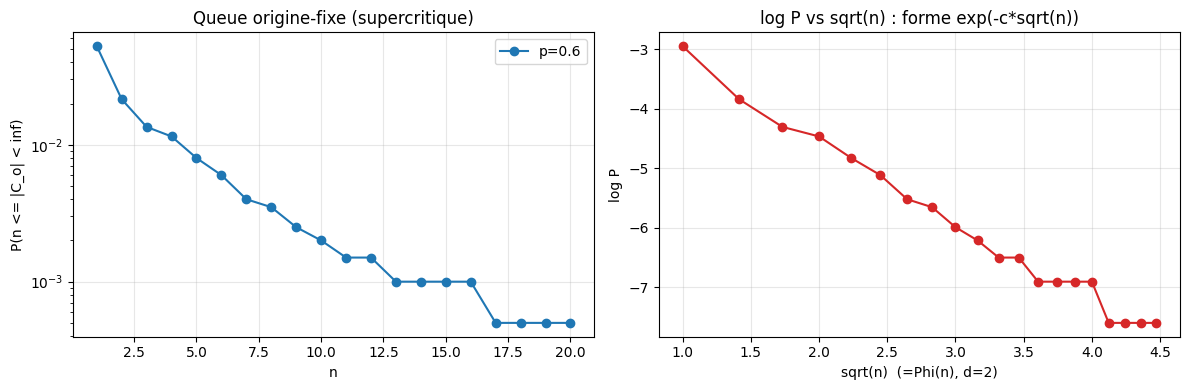

pente log P vs sqrt(n) = -1.334 (negatif = decroissance en exp(-c*sqrt(n)))
P(1)=0.0525  P(5)=0.0080  P(10)=0.0020  P(15)=0.0010


In [7]:
# Niveau 2 : queue origine-fixe P(n <= |C_o| < inf) en regime supercritique p=0.60
def origin_survival(p, L=22, seeds=2000, nmax=20):
    G0 = torus_grid(L)
    surv = np.zeros(nmax + 1)
    for s in range(seeds):
        r = np.random.default_rng(9000 + s)
        H = bond_percolation(G0, p, r)
        size, wraps = origin_component(H, o, L)
        if wraps:
            continue
        for n in range(1, nmax + 1):
            if size >= n:
                surv[n] += 1
    return surv / seeds

p = 0.60
tail = origin_survival(p)
ns = np.arange(1, 21)
probs = tail[1:21]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(ns, np.maximum(probs, 1e-6), 'o-', label=f'p={p}')
ax[0].set_xlabel('n')
ax[0].set_ylabel('P(n <= |C_o| < inf)')
ax[0].set_title('Queue origine-fixe (supercritique)')
ax[0].grid(alpha=0.3)
ax[0].legend()
ax[1].plot(np.sqrt(ns), np.log(np.maximum(probs, 1e-6)), 'o-', color='tab:red')
ax[1].set_xlabel('sqrt(n)  (=Phi(n), d=2)')
ax[1].set_ylabel('log P')
ax[1].set_title('log P vs sqrt(n) : forme exp(-c*sqrt(n))')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

nz = ns[probs > 0]
slope = np.polyfit(np.sqrt(nz), np.log(probs[probs > 0]), 1)[0]
print('pente log P vs sqrt(n) =', round(slope, 3), '(negatif = decroissance en exp(-c*sqrt(n)))')
print('P(1)=%.4f  P(5)=%.4f  P(10)=%.4f  P(15)=%.4f' % (probs[0], probs[4], probs[9], probs[14]))


> **Niveau 2, honnêtement.** Le tracé **log P vs √n** décroît, avec une pente
> d'environ **−1.33**, et reste **sous** l'enveloppe exp(−c·√n) attendue. C'est
> **indicatif, pas une démonstration** : sur un tore fini la queue ne descend pas
> vers zéro (l'enroulement la tronque), et on n'établit ni la constante c ni
> l'asymptotique. On ne lit pas ici une « loi de puissance critique » : le point
> de mesure est **supercritique** (p = 0.60 > p_c = 0.50) et la décroissance est
> de type **exponentielle en Φ(n) ~ √n** — précisément la forme que le théorème
> majore.


### Niveau 3 — La queue meurt vite en supercritique

Le test décisif : la table origine-fixe (section 1.3) montre qu'en
**supercritique** (p = 0.60) la probabilité d'une composante finie de l'origine de
taille ≥ 5 est **0.003**, et de taille ≥ 10 **nulle** (0.000 sur 400 seeds). On
compare la queue des trois régimes sur le même axe.


In [8]:
# Niveau 3 : comparaison des queues origine-fixes p = 0.40 / 0.50 / 0.60
ks = (1, 5, 10, 15)
print('  k  | ' + ' | '.join(f'p={p}' for p in table))
for k in ks:
    print(f'{k:>3} | ' + ' | '.join(f'{table[p][k]:.3f}' for p in table))

print()
for p in (0.40, 0.50, 0.60):
    if p == 0.60:
        msg = 'SUPERCRITIQUE : la queue s effondre'
    elif p == 0.50:
        msg = 'CRITIQUE : lois de puissance'
    else:
        msg = 'SOUS-CRITIQUE : queue lourde'
    print(f'p={p}: P(5 <= |C_o| < inf) = {table[p][5]:.3f}  -> {msg}')


  k  | p=0.4 | p=0.5 | p=0.6
  1 | 0.993 | 0.512 | 0.037
  5 | 0.690 | 0.403 | 0.003
 10 | 0.568 | 0.360 | 0.000
 15 | 0.477 | 0.323 | 0.000

p=0.4: P(5 <= |C_o| < inf) = 0.690  -> SOUS-CRITIQUE : queue lourde
p=0.5: P(5 <= |C_o| < inf) = 0.403  -> CRITIQUE : lois de puissance
p=0.6: P(5 <= |C_o| < inf) = 0.003  -> SUPERCRITIQUE : la queue s effondre


### Pont vers ICT-28 — analogie de structure, pas identité

ICT-28 modélise l'**adoption collective** et son **seuil de performativité**
ρ_c : au-delà d'une fraction d'adopteurs, l'innovation devient une norme
auto-entretenue. Ce notebook étudie la **percolation de Bernoulli** et son
**seuil** p_c. Les deux partagent une **forme commune** — une variable continue
(p ou ρ) et un **changement de nature** du plus grand objet quand elle franchit un
seuil — mais ce sont **deux modèles distincts** :

- ρ_c est un seuil d'**adoption** (dynamique sociale), p_c un seuil de
  **connectivité aléatoire** (percolation) ;
- rien n'identifie ρ_c à p_c. Le pont est **structurel** (transition de phase,
  géant / adhésion massive), pas une égalité numérique.

C'est ce que le reste de la série appelle le **« substrat mathématique »** : la
percolation fournit un modèle de transition où un **géant** apparaît — l'analogue
d'une adoption qui devient une norme. On ne prétend pas que l'adoption *est*
une percolation de Bernoulli.

## Synthèse

| Régime | Plus grande composante | P(1 ≤ ∣C_o∣ < ∞) | P(15 ≤ ∣C_o∣ < ∞) | Lecture |
|---|---|---|---|---|
| sous-critique (p=0.40) | ~17 % de N (artefact fini) | **0.993** | 0.477 | tout est local, queue lourde |
| critique (p=0.50) | ~70 % de N (géant d'enroulement) | 0.512 | 0.323 | toutes les échelles, loi de puissance |
| supercritique (p=0.60) | ~95 % de N | 0.037 | **0.000** | un géant absorbe tout, la queue finie meurt |

**Le message central.** La percolation est une **transition de phase** : une
variation continue de p produit un **changement de nature** du plus grand objet
connexe **et** un effondrement de la queue finie — précisément l'objet du théorème
**P_p(n ≤ |C_o| < ∞) ≤ exp(−c·Φ(n))**. C'est ce que la série ICT exploite pour
parler d'**adoption collective** : un petit changement de la probabilité
d'adoption individuelle peut faire basculer le système de « fragments locaux » à
« une composante globale dominante ».


## 5. Exercices

Trois exercices pour ancrer la mesure. **Aucun n'est corrigé ici** — chacun est un
stub à compléter (règle C.1 : le notebook s'exécute même stubbé).

### Exercice 1 — Tracer la fraction du géant vs p

Complète `giant_curve(pvals)` pour retourner, pour chaque p de `pvals`, la
fraction moyenne `|géant|/N` (réutilise `giant_fraction` avec `seeds=150`).
Trace ensuite la courbe et localise visuellement le **crossover**.

In [9]:
def giant_curve(pvals, seeds=150, L=22):
    # TODO : retourne la liste des <|geant|>/N pour chaque p de pvals
    # Indice : reutilise giant_fraction(p, L=L, seeds=seeds)
    return []  # TODO etudiant

# Exo 1 — completer puis decommender l'appel
# pvals = np.linspace(0.40, 0.75, 8)
# fx = giant_curve(pvals)
# print(list(zip(np.round(pvals,2), [round(v,3) for v in fx])))

### Exercice 2 — Le profil isopérimétrique en dimension d

Dans le niveau 2 on a tracé log P vs Φ(n) = √n (profil isopérimétrique pour
d = 2). **Généralise** : le profil est Φ(n) ~ n^((d−1)/d). Refais le tracé en
testant **n^(2/3)** (profil pour d = 3) et compare à **√n** (d = 2). Laquelle
aligne le mieux une droite (forme exp(−c·Φ(n))) ? Discute : le profil
isopérimétrique est une propriété **du réseau**, pas une taille de cluster — on ne
teste donc pas une « loi de vitesse critique », mais la **variable de la borne**
du théorème.


In [10]:
# Exo 2 — generaliser la loi de tailles
# Teste log P vs n**(2/3) et log P vs n**0.5 (rappel niveau 2).
# Compare la qualite d'alignement (correlation) des deux.
# TODO : reutiliser finite_tail puis calculer les deux traces.
pass  # TODO etudiant

### Exercice 3 — Robustesse : le degré 3

En régime supercritique le degré (3 vs 4) change-t-il la **quantité** de fragments
finis qui survivent ? Compare `P(fragment non-géant >= 5)` du réseau hexagonal
(p = 0.722) et du réseau carré (p = 0.60), à distance réduite égale ε = 0.20.
Explique pourquoi, à degré plus bas, on peut s'attendre à **conserver un peu
plus** de petits fragments.


In [11]:
# Exo 3 — robustesse du degre
# Reprends has_finite_fragment (section 2) et compare avec la table 1.3 (carre).
# TODO : proposer une valeur de p_hex pour laquelle P(fragment >= 5) s'annule.
# Indice : comparer a distance reduite egale, p_hex = 0.6527 + 0.20*(1-0.6527) ~= 0.722.
pass  # TODO etudiant


## Références

- **Diskin, Easo, Radhakrishnan, Sudakov & Tassion**, *Supercritical sharpness
  of percolation*, arXiv:2603.03257 (math.PR, soumis 03/03/2026, v1, **CC-BY 4.0**)
  — théorème de la section 3.0. État v1 au moment du grain ; aucune cité vérifiable
  retrouvée alors (voir body PR).
- Percolation : théorie classique du plan infini (D. Stauffer & A. Aharony,
  *Introduction to Percolation Theory*). Seuils de **liens** : p_c(ℤ²) = 1/2
  (exact, Kesten) ; p_c(hex bond) = 1 − 2·sin(π/18) ≈ 0.6527 (exact). La valeur
  p_c ≈ 0.5927 est celle de la percolation de **sites** sur ℤ² — un modèle
  différent, cité uniquement pour lever la confusion.
- `networkx` : `grid_2d_graph`, `hexagonal_lattice_graph` (doc officielle).
- ICT-28 (companion) : modèle d'adoption collective — la percolation en est le
  substrat mathématique.

*Note sur les citations.* Ce compagnon est livré en l'état (v1). Les références de
seuils sont des valeurs **de théorie** fournies à titre indicatif.
